In [1]:
# !unzip -o -q ./data/deepseek-new.zip -d ./data/

## Dependencies

In [2]:
import pandas as pd
import numpy as np

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score

from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.cli import tqdm
from tqdm import trange

from icecream import ic

import os

## Data Preparing

In [3]:
df_labled = pd.read_csv('./data/train.csv')
df_test = pd.read_csv('./data/test.csv')
df_labled.head()

,id,label
0,44263a6b,Scyther
1,9b6344f2,Butterfree
2,c89ffbde,Rhydon
3,95bbd7ff,Koffing
4,c3e8a9e1,Dewgong


In [4]:
df_test.head()

,id
0,9553b359
1,c6bcf2c2
2,5493d25f
3,f17f13b5
4,bb4e5386


### EDA

In [5]:
df_labled.shape

(5243, 2)

In [6]:
df_labled['label'].nunique()

150

<Axes: xlabel='label', ylabel='Count'>

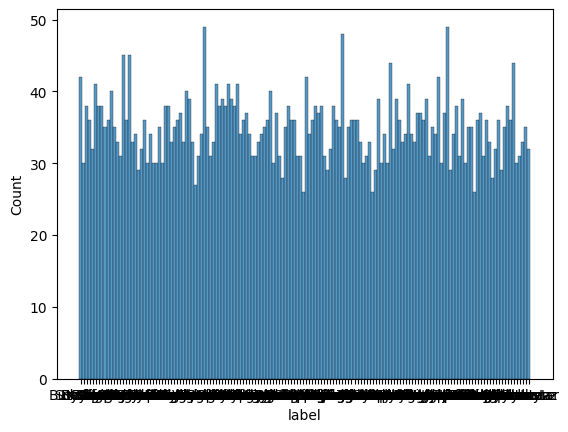

In [7]:
sns.histplot(df_labled, x='label')

In [8]:
df_train, df_val = train_test_split(df_labled, test_size=0.3, stratify=df_labled['label'], shuffle=True, random_state=42)
df_train.shape, df_val.shape

((3670, 2), (1573, 2))

<Axes: xlabel='label', ylabel='count'>

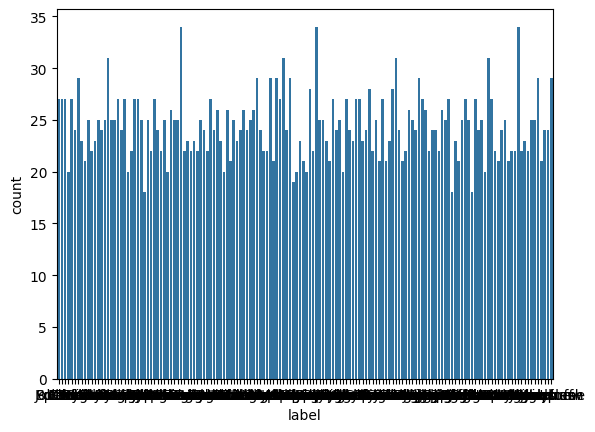

In [9]:
sns.countplot(data=df_train, x='label')

<Axes: xlabel='label', ylabel='count'>

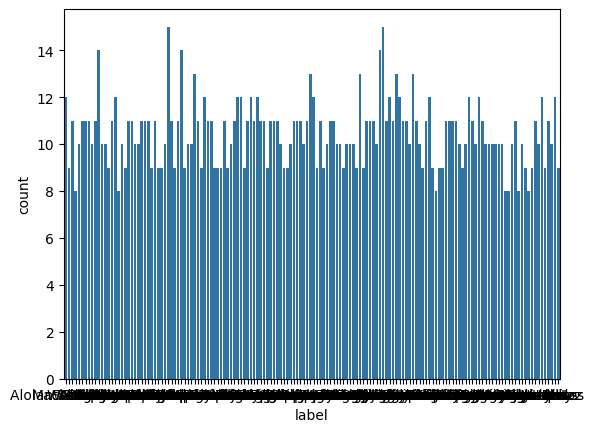

In [10]:
sns.countplot(data=df_val, x='label')

In [11]:
label_encoder = LabelEncoder()
label_encoder.fit(df_labled['label'])

LabelEncoder()

In [12]:
label_encoder.inverse_transform([0])

array(['Abra'], dtype=object)

In [13]:
label_encoder.transform(['Abra'])

array([0])

### Custom Dataset & Transforms

In [14]:
class PockemonDataset(Dataset):
    def __init__(self, df: pd.DataFrame, img_path: str, transform: transforms.Compose = None, is_test = False):
        super().__init__()

        self.df = df
        self.img_path = img_path
        self.transform = transform
        self.is_test = is_test

    def __len__(self):
        return self.df.shape[0]

    def __getitem__(self, index):
        id = self.df.iloc[index]['id']
        label = 0
        if not self.is_test:
            label = self.df.iloc[index]['label']
            label = label_encoder.transform([label])[0]

        img_path = os.path.join(self.img_path, f"{id}.jpg")
        img = Image.open(img_path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return (img, label)

In [15]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
    transforms.RandomRotation(40),
    transforms.GaussianBlur(3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

### DataLoaders

In [16]:
train_dataset = PockemonDataset(df_train, "./data/train", train_transforms)
val_dataset = PockemonDataset(df_val, "./data/train", test_transforms)
test_dataset = PockemonDataset(df_test, "./data/test", test_transforms)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5005665].


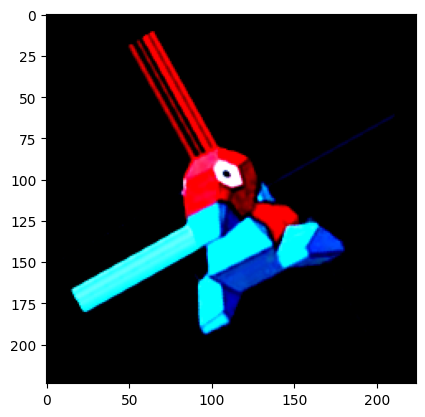

In [17]:
img_idx = np.random.randint(0, len(train_dataset))
img = train_dataset[img_idx][0].numpy()
img = np.transpose(img, (1, 2, 0))

plt.imshow(img)

In [18]:
train_dataloader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=8, persistent_workers=True)
val_dataloader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=8, persistent_workers=True)
test_dataloader = DataLoader(test_dataset, batch_size=128, shuffle=False)

## Training

### Train Loop

In [19]:
def train_loop(
        model: nn.Module,
        train_loader: DataLoader,
        val_loader: DataLoader,
        optimizer: torch.optim.AdamW,
        criterion = nn.CrossEntropyLoss(),
        num_epoches = 100,
        model_name = "best_model.pth"
    ):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    train_losses = []
    val_losses = []
    val_metrics = []

    for epoch in trange(num_epoches):
        model.train()
        cur_train_loss = 0.
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)

            optimizer.zero_grad()
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()

            cur_train_loss += loss.item()
        
        train_losses.append(cur_train_loss / len(train_loader))
        
        model.eval()
        cur_val_loss = 0.
        cur_preds = []
        val_labels = []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                y_pred = model(X_batch)

                loss = criterion(y_pred, y_batch)
                cur_val_loss += loss.item()

                y_pred = y_pred.detach().cpu().numpy()
                y_pred = np.argmax(y_pred, axis=1)
                y_batch = y_batch.cpu().numpy()

                val_labels.extend(y_batch)
                cur_preds.extend(y_pred)

        val_losses.append(cur_val_loss / len(val_loader))
        cur_metric = f1_score(val_labels, cur_preds, average='macro')
        if len(val_metrics) < 2 or cur_metric > max(val_metrics):
            torch.save(model.state_dict(), f"./models/{model_name}")
            print("!!! NEW BEST MODEL !!!")
        val_metrics.append(cur_metric)

        print(f"Epoch {epoch}: train_loss {train_losses[-1]}, val_loss {val_losses[-1]}, val_f1 {cur_metric}")
        
        if epoch % 10 == 0 or epoch == num_epoches - 1:
            if epoch == 0:
                continue
            
            fig, axs = plt.subplots(1, 2, figsize=(10, 4))

            axs[0].set_title("Losses")
            axs[0].plot(train_losses, label='Train')
            axs[0].plot(val_losses, label='Val')
            axs[0].legend()
            axs[0].grid(True)

            axs[1].set_title("val F1-score")
            axs[1].plot(val_metrics)
            axs[1].grid(True)

            plt.tight_layout()
            plt.show()

    print(f"Best score: {max(val_metrics)}")

    return model


### Model

In [20]:
class PockemonModel(nn.Module):
    def __init__(
            self,
            img_shape: tuple[int, int],
            in_ch: int,
            hidden_ch: list[int],
            hidden_fc: list[int],
            out_dim: int,
            conv_dropout = 0.2,
            fc_dropout = 0.3
        ):
        super(PockemonModel, self).__init__()

        self.img_shape = img_shape
        self.in_ch = in_ch

        conv_layers = []
        last_ch = in_ch
        for ch in hidden_ch:
            conv_layers.extend([
                nn.Conv2d(last_ch, ch, 3, padding=1),
                nn.BatchNorm2d(ch),
                nn.ReLU(),
                nn.Dropout2d(conv_dropout),
                nn.Conv2d(ch, ch, 3, padding=1),
                nn.BatchNorm2d(ch),
                nn.ReLU(),
                nn.Dropout2d(conv_dropout),
                nn.MaxPool2d(2, 2)
            ])
            last_ch = ch

        self.conv_net = nn.Sequential(*conv_layers)
        
        fc_layers = []
        last_dim = self._shape_after_conv(self.conv_net)
        for dim in hidden_fc:
            fc_layers.extend([
                nn.Linear(last_dim, dim),
                nn.BatchNorm1d(dim),
                nn.ReLU(),
                nn.Dropout1d(fc_dropout)
            ])
            last_dim = dim
        fc_layers.extend([
            nn.Linear(last_dim, out_dim)
        ])

        self.fc_net = nn.Sequential(*fc_layers)
        
    def forward(self, x):
        x = self.conv_net(x)
        flatten = nn.Flatten()
        x = flatten(x)
        x = self.fc_net(x)
        return x


    def _shape_after_conv(self, conv_block: nn.Module):
        A = torch.zeros(size=(1, self.in_ch, *self.img_shape))
        A = conv_block(A)
        flatten = nn.Flatten()
        A = flatten(A)
        return A.shape[1]
        


In [ ]:
model = ic(PockemonModel(
    img_shape=(224, 224),
    in_ch=3,
    hidden_ch=[32, 64, 128],
    hidden_fc=[512, 256, 128],
    out_dim=150
))

optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()

train_loop(
    model=model,
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    optimizer=optimizer,
    criterion=criterion,
    model_name="best_model_001.pth"
)


ic| PockemonModel(
        img_shape=(224, 224),
        in_ch=3,
        hidden_ch=[32, 64, 128],
        hidden_fc=[512, 256, 128],
        out_dim=150
    ): PockemonModel(
         (conv_net): Sequential(
           (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
           (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
           (2): ReLU()
           (3): Dropout2d(p=0.2, inplace=False)
           (4): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
           (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
           (6): ReLU()
           (7): Dropout2d(p=0.2, inplace=False)
           (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
           (9): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
           (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
           (11): ReLU()


KeyboardInterrupt: 